## Tutorial: Elastic inverse problems

This tutorial uses `triangulax` to study a geometric inverse problem: given a physical **forward model**, find parameters so that the simulation generates a target surface $\mathcal{S}_1$ from an initial state $\mathcal{S}_0$. Inverse problems are important both in engineering and design, as well as in fitting a model to experimental data. We saw a very simple inverse problem in tutorial 2, "mesh optimization". Now we will consider a more complex problem in 3d. From an ML perspective, the simulation is effectively treated like a "neural network" which maps initial conditions to simulation results, and simulation parameters as trainable "weights". 

For example, consider an elastic energy $E (\mathbf{v};  \boldsymbol{\theta})$ that depends on both mesh vertex positions $\mathbf{v}$ and parameters $\boldsymbol{\theta}$ (like elastic moduli or reference shapes). 
The output of the simulation is the minimum-energy configuration $\mathbf{v}^*(\boldsymbol{\theta}) = \arg \min E ( \cdot ;\theta)$. The goal is to find parameters $\boldsymbol{\theta}^*$ so that the equilibrated vertex positions $\mathbf{v}^*(\boldsymbol{\theta}^*)$ match the target shape. Via automatic differentiation, one can differentiate $\mathbf{v}^*(\boldsymbol{\theta})$ with respect to the parameters $\boldsymbol{\theta}$, and use gradient-based optimizers like ADAM to find the desired parameter value $\boldsymbol{\theta}^*$.

The optimization library `optimistix` and the ODE library `diffrax` allow automatically differentiating through complex simulations. More generally, differentiating through a simulation facilitates sensitivity analyses and fitting simulations to (experimental) data.

### Design of a shape-shifting material

In this notebook, we apply `triangulax` to the design of a shape shifting-material, a thin liquid crystal elastomer sheet (see [Aharon et al., 2014](http://dx.doi.org/10.1103/PhysRevLett.113.257801), [van Rees et al., 2017](http://www.pnas.org/cgi/doi/10.1073/pnas.1709025114), and [Aharoni et al., 2018](http://www.pnas.org/cgi/doi/10.1073/pnas.1804702115)). Our numerical implementation follows [Chen et al., 2018](https://doi.org/10.1145/3197517.3201395).

These sheets have a nematic direction imprinted. When heated, the material locally shrinks along the nematic director and expands in the orthogonal direction. To relax the elastic energy, the material changes shape and buckles into the third dimension. To control the curvature of the material, one can glue together two sheets with different directors. Differences in strain across the two layers induces curvature. The goal is to paint two nematic director fields onto the surface so that the elastically relaxed shape after heating matches a desired target.  Because the elastomer shrinks and contracts by equal amounts, the problem is constrained: it is not possible to "morph" each piece of the material into the target shape.

#### Suzanne

As a toy problem, we will aim for a nematic pattern on an initially spherical surfaces that reproduces "Suzanne", a mesh model of a monkey's head that is a common test case in the 3d software Blender:

<div>
<img src="suzanne.png" width="500"/>
</div>


#### Elastic energy

The elastic energy combines an in-plane and a bending contribution, using the framework of **metric elasticity**. The physical and "target" shape of an elastic sheet are described by two metric tensors, $g$ and $g_r$.

For the in-plane/stretch term, we use the St.-Venant-Kirchhoff elastic energy:

$$E_{\mathrm{SK}} = \frac{h}{4} \int dA \left[\alpha \, (\mathrm{tr}[g_r^{-1} \cdot g - \mathbb{I}])^2 + 2\beta \, \mathrm{tr}\!\left[(g_r^{-1} \cdot g - \mathbb{I})^2\right] \right]$$
where $\alpha,\beta$ are Lamé coefficients and $g_r^{-1} \cdot g - \mathbb{I}$ is a measure of strain (2x the Green-Lagrange strain tensor). The `elastic` module implements a discrete version of this energy, by computing the metric $g$ for each triangle from the 3D vertex positions. The integral becomes a sum over all triangles. The overall scale is set by the shell thickness $h$.

Bending resistance is modeled using the **2nd fundamental form** $b$, which quantifies the extrinsic curvature of the surface:
$$E_{\mathrm{B}} = \frac{h^3}{12} \int dA \left[\alpha \, \mathrm{tr}\!\left(g_r^{-1}(b-b_r)\right)^2 + 2\beta \, \mathrm{tr}\!\left((g_r^{-1}(b-b_r))^2\right) \right]$$
The overall scale is set by $h^3$: thin shells are much easier to bend than to stretch, as one may verify using a sheet of paper.
$b_r$ is the target curvature. 
The combination of bending and stretching energy $E_{\mathrm{SK}} + E_{\mathrm{B}}$ is called the "Koiter" shell energy.

One way to generate target curvature is a bilayer with two different target metrics $g_r^{t}, g_r^{b}$ (for top and bottom). Van Rees et al. showed that a bilayer is equivalent to a monolayer with

$$g_r = \frac{1}{2}(g_r^{t} + g_r^{b}), \quad b_r = \frac{3}{4h}(g_r^{t} - g_r^{b})$$

**Sign convention**: `triangulax` uses the "positive-convex" convention (a sphere with outward-pointing normals has $b = +g$), and the *top* layer is the side the face normals point to. With the $+$ sign above, an expanding top layer creates positive target curvature.

#### Elastomers

Upon heating, a liquid crystal elastomer contracts along the local nematic director and expands orthogonal to it. In this model, this is captured by the _reference metric_. Initially, the reference metric equals the physical metric of the initial shape $\mathcal{S}_0$, $g_r = g_0$.

The change of target shape upon heating is described by a local strain tensor
$$\Lambda(\theta) = R(\theta)^T \cdot \begin{pmatrix} \lambda & 0 \\ 0 & 1/\lambda \end{pmatrix} \cdot R(\theta) $$
where $R$ is a rotation matrix, $\theta$ the local nematic angle, and $\lambda$ the local expansion ratio along the director (by convention, $\lambda < 1$ for a heated elastomer; choosing $\lambda > 1$ is equivalent up to a rotation of the pattern). Since $\det \Lambda = 1$, the actuation is locally **area-preserving**, which constrains the reachable target shapes. The reference metric deforms according to
$$g_r = \Lambda^T \cdot g_0 \cdot \Lambda$$

**Important — frames**: 

The angles $\theta^t, \theta^b$ are encoded per triangle, as an angle w.r.t. the first edge of the triangle. In the discrete elastic energies, the metric tensor and the curvature form are expressed in the basis of the triangle edges.

However, the rotation-matrix form of $\Lambda$ holds in an *orthonormal* frame, but the discrete metrics of the `elastic` module are expressed in the (non-orthonormal) basis of the triangle edges. For a triangle with vertices $a, b, c$, the edges are $u = b-a$, $v = c-a$, and the metric in the edge basis becomes
$$g = \begin{pmatrix} u^2 & u\cdot v \\ v\cdot u & v^2 \end{pmatrix}$$
We therefore use a change of basis $B$ per triangle which moves from the $u,v$ basis to an orthogonal basis.
The rows of $B$ are the edge vectors in the orthonormal frame with $e_1=u / |u|$ and $e_2 \perp e_1, |e_2| = 1$. In the $B$-basis, $g_B = \mathbb{I}$ so that in the edge basis, $g = B^T B$. The actuated reference metric in the edge basis is then
$$g_r = B^T \cdot \Lambda(\theta)^T\Lambda(\theta) \cdot B, \qquad \Lambda^T\Lambda = \frac{\lambda^2 + \lambda^{-2}}{2}\,\mathbb{I} + \frac{\lambda^2 - \lambda^{-2}}{2}\begin{pmatrix} \cos 2\theta & \sin 2\theta \\ \sin 2\theta & -\cos 2\theta \end{pmatrix}$$
The $2\theta$-dependence makes explicit that the director is a *nematic* (headless) degree of freedom: $\theta$ and $\theta + \pi$ are the same state.

For a bilayer elastomer, there are two local nematic orientations $\theta^t, \theta^b$ that control the reference metrics of the top and bottom sheet. As we saw above, this is equivalent to changing the reference curvature of the sheet.

#### Inverse design

Our goal will be to program the local nematic orientations $\theta^t, \theta^b$ so that an initially spherical mesh turns into a target shape.
Given a nematic pattern $\theta^t, \theta^b$, we simulate forward by minimizing the elastic energy. We can then compute a loss: the mean squared difference between the final vertex positions and the target. We can add extra terms to the loss, for example, encouraging smooth nematic fields.
To solve the inverse design problem, we minimize the loss w.r.t. $\theta^t, \theta^b$ using gradient-based optimization (the ADAM optimizer from `optax`). The gradient of the loss requires differentiating *through* the energy minimization $\mathbf{v}^*(\boldsymbol{\theta}) = \arg\min E(\cdot\,; \boldsymbol{\theta})$: `optimistix` does this automatically via the implicit function theorem (no need to backpropagate through the iterations of the inner optimizer).

Since the elastic energy is invariant under rigid motions (translations and rotations), we first align the relaxed shape to the target with the differentiable [Kabsch algorithm](https://en.wikipedia.org/wiki/Kabsch_algorithm).



#### Targets

Before we turn to Suzanne, we will try this on less complex targets:

1. A *teacher* shape generated by the forward model itself (so we know a solution exists and can compare the recovered pattern to the ground truth).

2. A hand-designed deformed sphere (an ellipsoid).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import meshplot
import igl

from IPython.display import IFrame

In [2]:
import jax.numpy as jnp
import jax

In [3]:
jax.config.update("jax_enable_x64", True)
# note: keep jax_debug_nans off. the line searches inside the minimizers produce
# (safely handled) NaNs that would trigger false positives
jax.config.update("jax_debug_nans", False)

In [4]:
from jaxtyping import Float

In [5]:
import equinox

In [6]:
import lineax
import optimistix
import optax

In [7]:
from triangulax import geometry as geom
from triangulax import elastic
from triangulax import algorithms as algo
from triangulax import topology as topo
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh

### Load mesh

We start with a very coarse unit sphere (42 vertices) so that experiments run in seconds. The sphere serves as both the initial condition and the rest configuration of the shell.

In [8]:
def load_sphere(name):
    """Loads, centers, and scales a sphere mesh from the tutorial_meshes/ directory."""
    mesh = TriMesh.read_obj(f"tutorial_meshes/{name}.obj", dim=3)
    vertices = mesh.vertices - mesh.vertices.mean(axis=0)
    vertices = jnp.asarray((vertices.T / np.linalg.norm(vertices, axis=1)).T)
    return vertices, HeMesh.from_triangles(vertices.shape[0], mesh.faces)

v0, hemesh = load_sphere("sphere")
metric_rest = elastic.get_metric(v0, hemesh)
b_rest = elastic.get_second_fundamental_form(v0, hemesh)

thickness, lam = 0.1, 1.1  # shell thickness h and nematic expansion ratio lambda
hemesh

  o Icosphere


HeMesh(N_V=42, N_HE=240, N_F=80)

### Programming the reference metric with nematic directors

We now implement the actuation: per-face director angles $\theta^t, \theta^b \mapsto$ reference metric $g_r$ and reference curvature $b_r$, following the formulas above.

In [9]:
def get_face_basis_from_metric(metric):
    """Per-face upper-triangular B with metric = B^T B (columns = edge vectors u, v
    in the orthonormal face frame e1 = u/|u|, e2 in-plane perpendicular)."""
    g00, g01 = metric[..., 0, 0], metric[..., 0, 1]
    det, sq = jnp.linalg.det(metric), jnp.sqrt(metric[..., 0, 0])
    zero = jnp.zeros_like(g00)
    return jnp.stack([jnp.stack([sq, g01 / sq], axis=-1),
                      jnp.stack([zero, jnp.sqrt(det) / sq], axis=-1)], axis=-2)


def get_nematic_metric(theta, lam, metric_rest):
    """Reference metric after nematic actuation: stretch lam along the director
    (angle theta from the first triangle edge), 1/lam orthogonal. Area-preserving.
    Final argument is the reference metric, which is used to compute the face basis
    in which the nematic metric is evaluated.
    """
    m = (lam**2 + lam**-2) / 2
    d = (lam**2 - lam**-2) / 2
    c2, s2 = jnp.cos(2 * theta), jnp.sin(2 * theta)
    Lam2 = jnp.stack([jnp.stack([m + d * c2, d * s2], axis=-1),
                      jnp.stack([d * s2, m - d * c2], axis=-1)], axis=-2)
    B = get_face_basis_from_metric(metric_rest)
    return jnp.einsum("...ji,...jk,...kl->...il", B, Lam2, B)


def get_bilayer_metric_and_curvature(theta_top, theta_bot, lam, metric_rest, b_rest, thickness):
    """Monolayer-equivalent (metric_ref, b_ref) for a bilayer with two director fields
    (van Rees et al. 2017). Top layer = side the face normals point to."""
    g_top = get_nematic_metric(theta_top, lam, metric_rest)
    g_bot = get_nematic_metric(theta_bot, lam, metric_rest)
    return (g_top + g_bot) / 2, b_rest + 3 / (4 * thickness) * (g_top - g_bot)

In [10]:
# tests: B^T B recovers the metric; lam=1 is the identity; actuation is area-preserving
B = get_face_basis_from_metric(metric_rest)
assert np.allclose(jnp.einsum("fji,fjk->fik", B, B), metric_rest)
assert np.allclose(get_nematic_metric(jnp.zeros(hemesh.n_faces), 1.0, metric_rest), metric_rest)
g_nem = get_nematic_metric(jnp.linspace(0, np.pi, hemesh.n_faces), lam, metric_rest)
assert np.allclose(jnp.linalg.det(g_nem), jnp.linalg.det(metric_rest))

In [11]:
# to define smooth test patterns and to visualize directors, we need the orthonormal
# face frames (e1 along the first edge) in 3D world coordinates

def angle_from_global_direction(D, vertices, hemesh):
    """Per-face director angle (w.r.t. first edge) of a global 3D direction D
    projected onto each face."""
    e1, e2 = geom.get_face_tangent_basis(vertices, hemesh)
    D = jnp.broadcast_to(D, e1.shape)
    return jnp.arctan2(jnp.sum(D * e2, axis=-1), jnp.sum(D * e1, axis=-1))


def director_segments(theta, vertices, hemesh, scale=0.1, offset=0.0):
    """Line segments visualizing a per-face director field (for meshplot.add_lines)."""
    e1, e2 = geom.get_face_tangent_basis(vertices, hemesh)
    d = jnp.cos(theta)[:, None] * e1 + jnp.sin(theta)[:, None] * e2
    centroids = geom.get_face_centroids(vertices, hemesh) + offset
    return np.array(centroids - scale * d), np.array(centroids + scale * d)

In [12]:
# example: the projection of the z-axis onto the sphere gives a smooth director
# field with defects at the poles (a nematic field on a sphere must have defects!)
theta_example = angle_from_global_direction(jnp.array([0., 0., 1.]), v0, hemesh)

p = meshplot.plot(np.array(v0), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)
p.add_lines(*director_segments(theta_example, v0, hemesh), shading={"line_color": "red"})
p.save("tutorial_plots/06_director_field.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/06_director_field.html.


In [13]:
IFrame(src="tutorial_plots/06_director_field.html", width="100%", height=400) # for display in docs webpage

### Forward model: elastic relaxation

The forward model relaxes the shell to its energy minimum for given director fields. The total energy is the sum of the St.-Venant-Kirchhoff in-plane and bending energies with the thickness scaling from above. We minimize with BFGS (the mesh is small; for larger meshes, use `optimistix.NonlinearCG` or a limited-memory method).

In [14]:
def get_shell_energy(vertices, args):
    """Koiter shell energy: E = h/4 * E_SK(g_r) + h^3/12 * E_B(g_r, b_r)."""
    hemesh, metric_ref, b_ref, thickness = args
    E_s = elastic.get_st_venant_kirchhoff_energy(vertices, (hemesh, metric_ref, 1.0, 1.0))
    E_b = elastic.get_svk_bending_energy(vertices, (hemesh, metric_ref, b_ref, 1.0, 1.0))
    return thickness / 4 * E_s + thickness**3 / 12 * E_b

solver = optimistix.BFGS(rtol=1e-10, atol=1e-10)

def relax_shell(theta_top, theta_bot, v_init, hemesh, metric_rest, b_rest,
                return_stats=False):
    """Minimize the shell energy for a given nematic pattern (differentiable)."""
    metric_ref, b_ref = get_bilayer_metric_and_curvature(theta_top, theta_bot, lam,
                                                         metric_rest, b_rest, thickness)
    sol = optimistix.minimise(get_shell_energy, solver, v_init,
                              (hemesh, metric_ref, b_ref, thickness),
                              max_steps=4000, throw=False)
    return (sol.value, sol.stats["num_steps"]) if return_stats else sol.value

In [15]:
# at lam = 1 (no actuation), the sphere is the exact rest state
metric_ref, b_ref = get_bilayer_metric_and_curvature(jnp.zeros(hemesh.n_faces),
                                                     jnp.zeros(hemesh.n_faces),
                                                     1.0, metric_rest, b_rest, thickness)
args = (hemesh, metric_ref, b_ref, thickness)
assert np.isclose(get_shell_energy(v0, args), 0.0, atol=1e-12)
assert np.allclose(jax.grad(get_shell_energy)(v0, args), 0.0, atol=1e-10)

In [16]:
#| hide

# sanity check of the bilayer sign convention: the "bimetallic strip".
# isotropically expand only the top layer of a flat disk:
# the disk must bow so the expanded layer is on the convex side,
# i.e. mean curvature H > 0 in triangulax's positive-convex convention
disk = TriMesh.read_obj("tutorial_meshes/disk.obj", dim=3)
disk_hemesh = HeMesh.from_triangles(disk.vertices.shape[0], disk.faces)
vd = jnp.asarray(disk.vertices)
g0_d = elastic.get_metric(vd, disk_hemesh)
b0_d = elastic.get_second_fundamental_form(vd, disk_hemesh)

g_top, g_bot = 1.1 * g0_d, g0_d
args_d = (disk_hemesh, (g_top + g_bot) / 2, b0_d + 3 / (4 * thickness) * (g_top - g_bot),
          thickness)
sol_d = optimistix.minimise(get_shell_energy, solver, vd, args_d, max_steps=5000, throw=False)
H_disk = geom.get_mean_curvature_dihedral(sol_d.value, disk_hemesh)
H_mean = H_disk[~np.asarray(disk_hemesh.is_bdry)].mean()
print(f"mean curvature of the bowed disk: {H_mean:+.3f}")
assert H_mean > 0

  o flat_tri_ecmc


mean curvature of the bowed disk: +0.466


#### What does a nematic pattern do?

Let's actuate the sphere with a simple hand-picked *teacher* pattern where the top director is along the (projected) $z$-axis. If the bottom director is parallel to the top, the sphere is stretched along the $z$ axis.
Orthogonal directors in the two layers create a large metric mismatch, i.e. mainly a change of the reference *curvature*. This leads to buckling.

In [17]:
theta_teacher_top = angle_from_global_direction(jnp.array([0., 0., 1.]), v0, hemesh)

#theta_teacher_bot = theta_teacher_top  # equal top and bottom directors
theta_teacher_bot = theta_teacher_top + np.pi / 2 # opposite top and bottom directors

v_teacher = relax_shell(theta_teacher_top, theta_teacher_bot, v0, hemesh, metric_rest, b_rest)
displacement = jnp.linalg.norm(v_teacher - v0, axis=-1)
print(f"max displacement: {displacement.max():.3f} (sphere radius 1)")

p = meshplot.plot(np.array(v0), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)
p.add_mesh(np.array(v_teacher) + np.array([2.5, 0, 0]), np.array(hemesh.faces),
           shading={"wireframe": True})
p.save("tutorial_plots/06_teacher_forward.html")

max displacement: 0.393 (sphere radius 1)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Plot saved to file tutorial_plots/06_teacher_forward.html.


In [18]:
IFrame(src="tutorial_plots/06_teacher_forward.html", width="100%", height=400)

### Inverse design 1: recovering a hidden nematic pattern

We now treat the deformed shape produced by the teacher pattern as the *target*, forget the pattern, and try to recover it from the shape alone by gradient descent through the simulation. This is the cleanest first test: we know the target is exactly reachable.

Two ingredients:

- **Alignment**: the elastic energy is invariant under rigid motions, so we align the relaxed shape to the target with the (differentiable) Kabsch algorithm before comparing.
- **Smoothness regularization**: to encourage smooth director fields, we penalize differences of the nematic **Q-tensor** $Q = d \otimes d - \mathbb{I}/2$ between adjacent faces (where $d$ is the unit director in 3D world coordinates). This respects the nematic gauge symmetry $\theta \sim \theta + \pi$ and ensures valid comparison across different faces.


#### 2nd-level optimizer

To minimize the elastic energy, we used a "classical" optimization algorithm (BFGS, or CG). For the 2nd level of optimization (over the model parameters), we use the ADAM optimizer, a standard choice in machine learning. ADAM is better suited to large-scale problems.

In [19]:
from triangulax.algorithms import kabsch_align

In [20]:
def make_loss(v_target, v_frames, hemesh, metric_rest, b_rest, reg=0.0):
    """Loss = mean squared vertex distance after alignment + Q-tensor smoothness.

    The returned loss(params, v_init) relaxes the shell starting from v_init: pass the
    rest configuration for a cold start, or the previous equilibrium for a warm start.
    The equilibrium v* and the inner solver step count are returned as auxiliary outputs.
    v_frames sets the face frames used by the smoothness regularizer.
    """
    e1, e2 = geom.get_face_tangent_basis(v_frames, hemesh)
    f1, f2 = hemesh.heface, hemesh.heface[hemesh.twin]
    interior = hemesh.is_unique & ~hemesh.is_bdry_edge

    def smoothness(theta):
        d = jnp.cos(theta)[:, None] * e1 + jnp.sin(theta)[:, None] * e2
        Q = d[:, :, None] * d[:, None, :] - jnp.eye(3) / 2
        dQ = ((Q[f1] - Q[f2]) ** 2).sum(axis=(-1, -2))
        return jnp.where(interior, dQ, 0.0).sum() / interior.sum()

    def loss(params, v_init):
        theta_top, theta_bot = params
        v_star, n_steps = relax_shell(theta_top, theta_bot, v_init, hemesh,
                                      metric_rest, b_rest, return_stats=True)
        fit = jnp.mean((kabsch_align(v_star, v_target)[0] - v_target) ** 2)
        total = fit + reg * (smoothness(theta_top) + smoothness(theta_bot))
        return total, (fit, v_star, n_steps)

    return loss

In [21]:
# check the gradient through the energy minimization against finite differences
loss = make_loss(v_teacher, v0, hemesh, metric_rest, b_rest)
params = (jnp.zeros(hemesh.n_faces), jnp.zeros(hemesh.n_faces))
(L, (fit, v_recovered_initial, _)), grads = jax.value_and_grad(loss, has_aux=True)(params, v0)

eps = 1e-5
L_pert, _ = loss((params[0].at[3].add(eps), params[1]), v0)
fd = (L_pert - L) / eps
print(f"autodiff {grads[0][3]:.6e} vs finite difference {fd:.6e}")
assert np.isclose(grads[0][3], fd, rtol=0.05)

autodiff 1.678056e-05 vs finite difference 1.721815e-05


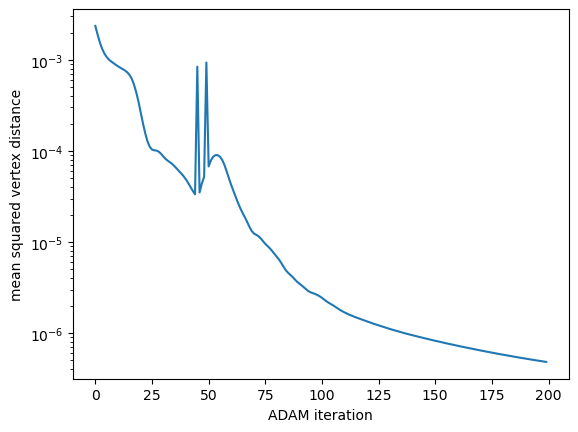

In [22]:
# ADAM loop. on this coarse mesh, each iteration (forward relaxation + implicit
# backward pass) takes a few milliseconds once compiled
value_and_grad = jax.jit(jax.value_and_grad(loss, has_aux=True))

optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)
history = []
for k in range(200):
    (L, (fit, _, _)), grads = value_and_grad(params, v0)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    history.append(fit)

plt.semilogy(history)
plt.xlabel("ADAM iteration"); plt.ylabel("mean squared vertex distance");

In [23]:
# the recovered pattern reproduces the target shape to a fraction of a percent ...
v_recovered = relax_shell(*params, v0, hemesh, metric_rest, b_rest)
err = jnp.linalg.norm(kabsch_align(v_recovered, v_teacher)[0] - v_teacher, axis=-1)
print(f"max vertex error {err.max():.4f} vs target displacement scale {displacement.max():.3f}")

max vertex error 0.0019 vs target displacement scale 0.393


In [24]:
# plot the initial and final recovered shapes next to the teacher shape
p = meshplot.plot(np.array(v_recovered_initial), np.array(hemesh.faces), shading={"wireframe": True},
                  return_plot=True)

p.add_mesh(np.array(v_recovered) + np.array([2.5, 0, 0]), np.array(hemesh.faces), shading={"wireframe": True},)

p.add_mesh(np.array(v_teacher) + np.array([5, 0, 0]), np.array(hemesh.faces), shading={"wireframe": True})
p.save("tutorial_plots/06_teacher_vs_student.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0145729…

Plot saved to file tutorial_plots/06_teacher_vs_student.html.


In [25]:
IFrame(src="tutorial_plots/06_teacher_vs_student.html", width="100%", height=400)

median director angle error: 24.0 deg


<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/vm/1jl6rjln6n9cjt54vsr9n4800000gr/T/ipykernel_36464/1643597439.py:8: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.xlabel(r"teacher angle $\theta^t$ (mod $\pi$)"); plt.ylabel("recovered angle (mod $\pi$)");


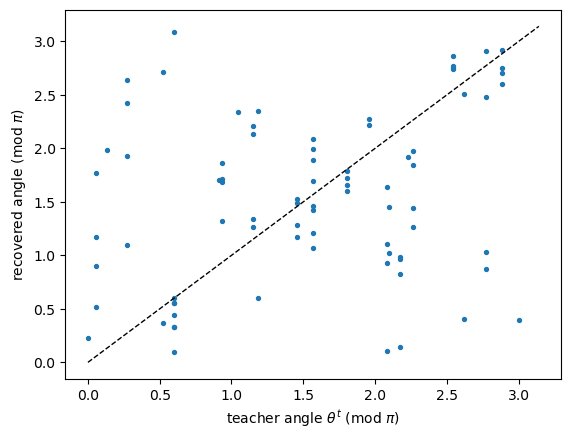

In [26]:
# Let's plot the recovered director field and the hidden teacher pattern

delta = (params[0] - theta_teacher_top + np.pi / 2) % np.pi - np.pi / 2
print(f"median director angle error: {np.degrees(np.median(np.abs(delta))):.1f} deg")

plt.scatter(theta_teacher_top % np.pi, params[0] % np.pi, s=8)
plt.plot([0, np.pi], [0, np.pi], "k--", lw=1)
plt.xlabel(r"teacher angle $\theta^t$ (mod $\pi$)"); plt.ylabel("recovered angle (mod $\pi$)");

The shape is reproduced almost exactly — but the *pattern* is only partially identified: the difference between teacher and student parameters is substantial.  The reason is that many patterns produce similar relaxed shapes. This non-uniqueness is a generic feature of inverse problems. Adding the smoothness regularizer selects *one* well-behaved solution (with smooth director fields) among the near-degenerate ones. But this is not necessarily the teacher pattern (you can check by `reg`).

### Inverse design 2: a hand-designed target

Now for a real design task: deform the sphere into a *prescribed* shape, in this case, an ellipsoid. Unlike the teacher target, an ellipsoid is generally **not exactly reachable**: the nematic actuation is locally area-preserving ($\det \Lambda = 1$) and the expansion ratio is fixed at $\lambda$, so the design space is constrained. Gradient descent will find the best compromise.

fit 6.18e-03 -> 5.66e-04, max vertex error 0.054 (target displacement scale 0.20)


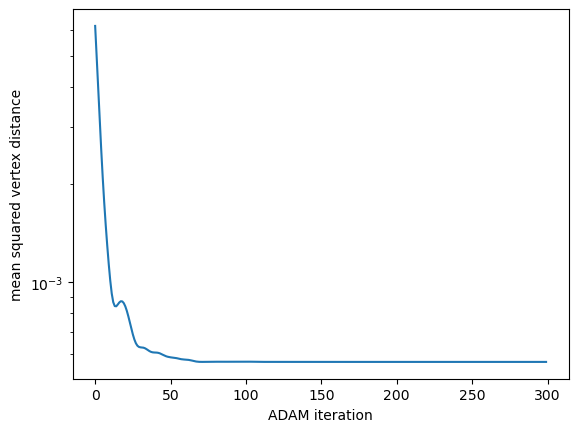

In [27]:
v_ellipsoid = v0 * jnp.array([0.95, 0.95, 1.2])

loss = make_loss(v_ellipsoid, v0, hemesh, metric_rest, b_rest, reg=1e-3)
value_and_grad = jax.jit(jax.value_and_grad(loss, has_aux=True))

params = (jnp.zeros(hemesh.n_faces), jnp.zeros(hemesh.n_faces))
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)
history = []
for k in range(300):
    (L, (fit, _, _)), grads = value_and_grad(params, v0)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    history.append(fit)

v_designed = relax_shell(*params, v0, hemesh, metric_rest, b_rest)
err = jnp.linalg.norm(kabsch_align(v_designed, v_ellipsoid)[0] - v_ellipsoid, axis=-1)
print(f"fit {history[0]:.2e} -> {history[-1]:.2e}, max vertex error {err.max():.3f} "
      f"(target displacement scale {jnp.linalg.norm(v_ellipsoid - v0, axis=-1).max():.2f})")

plt.semilogy(history)
plt.xlabel("ADAM iteration"); plt.ylabel("mean squared vertex distance");

In [28]:
# left: designed shape (colored by vertex error, with the optimized top director
# field); right: the ellipsoid target
p = meshplot.plot(np.array(v_designed), np.array(hemesh.faces), np.array(err),
                  shading={"wireframe": True}, return_plot=True)
p.add_lines(*director_segments(params[0], v_designed, hemesh), shading={"line_color": "red"})
p.add_mesh(np.array(v_ellipsoid) + np.array([2.5, 0, 0]), np.array(hemesh.faces),
           shading={"wireframe": True})
p.save("tutorial_plots/06_ellipsoid_design.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.002155…

Plot saved to file tutorial_plots/06_ellipsoid_design.html.


In [29]:
IFrame(src="tutorial_plots/06_ellipsoid_design.html", width="100%", height=400)

### Scaling up

The same code runs on finer meshes, only slower. The inner elastic energy relaxation via BFGS dominates. On a 642-vertex sphere, one ADAM iteration takes on the order of a second. Since `make_loss` exposes the relaxation starting point, we can **warm-start** each relaxation from the equilibrium of the previous outer iteration: after the first few outer steps, the parameters (and hence the equilibrium) change only a little per iteration, so the inner solver needs far fewer steps.

Two caveats, which we verify below:

- The speedup is smaller than the reduction in inner steps suggests, because the implicit-differentiation backward pass (a linear solve with the equilibrium Hessian) costs the same either way — on this mesh it is actually *more* expensive than the warm-started forward relaxation.
- The *gradient formula* is unaffected (implicit differentiation only sees the converged equilibrium), but *which* equilibrium the solver finds can depend on the starting point. Always verify the final design with a cold restart: here the fits agree to all digits, so warm-starting is safe. On rugged energy landscapes this check can fail — we will encounter this for Suzanne below.

In [30]:
v0_fine, hemesh_fine = load_sphere("sphere_fine")
metric_rest_fine = elastic.get_metric(v0_fine, hemesh_fine)
b_rest_fine = elastic.get_second_fundamental_form(v0_fine, hemesh_fine)
v_target_fine = v0_fine * jnp.array([0.95, 0.95, 1.2])

loss = make_loss(v_target_fine, v0_fine, hemesh_fine, metric_rest_fine, b_rest_fine, reg=1e-3)
value_and_grad = jax.jit(jax.value_and_grad(loss, has_aux=True))


def run_adam(warm_start, n_iters=150, learning_rate=0.1):
    """Outer ADAM loop; warm_start=True reuses the previous equilibrium."""
    params = (jnp.zeros(hemesh_fine.n_faces), jnp.zeros(hemesh_fine.n_faces))
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    v_current, history, inner_steps = v0_fine, [], []
    for k in range(n_iters):
        (L, (fit, v_star, n_steps)), grads = value_and_grad(params, v_current)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        history.append(fit)
        inner_steps.append(int(n_steps))
        if warm_start:
            v_current = v_star
    return params, history, inner_steps


import time
_ = value_and_grad((jnp.zeros(hemesh_fine.n_faces),) * 2, v0_fine)  # compile once

t0 = time.time(); params_cold, hist_cold, steps_cold = run_adam(False); t_cold = time.time() - t0
t0 = time.time(); params, history_fine, steps_warm = run_adam(True); t_warm = time.time() - t0

print(f"cold start: {t_cold:.0f}s, median inner BFGS steps {int(np.median(steps_cold))}, "
      f"final fit {hist_cold[-1]:.2e}")
print(f"warm start: {t_warm:.0f}s, median inner BFGS steps {int(np.median(steps_warm))}, "
      f"final fit {history_fine[-1]:.2e}")

v_designed_fine = relax_shell(*params, v0_fine, hemesh_fine, metric_rest_fine, b_rest_fine)
err_fine = jnp.linalg.norm(kabsch_align(v_designed_fine, v_target_fine)[0] - v_target_fine,
                           axis=-1)
print(f"max vertex error {err_fine.max():.3f}")

  o Icosphere


cold start: 110s, median inner BFGS steps 299, final fit 5.27e-04
warm start: 98s, median inner BFGS steps 246, final fit 5.27e-04


max vertex error 0.051


The final result shows a beautiful nematic pattern with two $1/2$ defects on the poles of the ellipsoid.

In [31]:
p = meshplot.plot(np.array(v_designed_fine), np.array(hemesh_fine.faces), np.array(err_fine),
                  shading={"wireframe": False}, return_plot=True)
p.add_lines(*director_segments(params[0], v_designed_fine, hemesh_fine, scale=0.05),
            shading={"line_color": "red"})
p.add_mesh(np.array(v_target_fine) + np.array([2.5, 0, 0]), np.array(hemesh_fine.faces),
           shading={"wireframe": False})
p.save("tutorial_plots/06_ellipsoid_design_fine.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0003275…

Plot saved to file tutorial_plots/06_ellipsoid_design_fine.html.


In [32]:
IFrame(src="tutorial_plots/06_ellipsoid_design_fine.html", width="100%", height=400)

### Suzanne

Generating `suzanne` from the introduction from an initially spherical mesh will require a more complex pattern than an ellipsoid. We expect the outer optimizer to take longer. We will use the techniques from above to accelerate the solver (Suzanne has 507 vertices).

Second, we need to rethink our loss function. If we start our simulation from the `sphere_fine.obj` mesh, we will have to compare meshes with *different* connectivity (simulation output vs Suzanne). For example, we could Kabsch-align the output and target mesh and compute the Chamfer distance:
$$\mathrm{Chamfer}(A, B) = \sum_{a\in A} \min_{b\in B} |a-b|^2 $$
where $A$ and $B$ are the two meshes' vertex sets. This can be implemented using the closest-point queries of the `interp` module. Finding a good metric to compare meshes is challenging, and at the heart of [active research in inverse design](https://arxiv.org/abs/2512.17129). Also, because the nematic deformation is locally area-preserving, the target shape may not be reachable at all.

Therefore, we **side-step** the difficult mesh-mesh alignment problem. Instead, we turn the problem on its head. We start with the `suzanne.obj` mesh and attempt to find a nematic pattern that turns `suzanne` into a sphere (of arbitrary radius). For our loss function, we only need to evaluate whether the relaxed mesh vertices lie on a sphere! Note that the position of the vertices in the final shape is now only constrained in the normal direction - we do not care where the vertices lie on the sphere. (NB: we may need to add penalty terms that ensures that the relaxed mesh configuration is valid, e.g. no flipped triangles.)


#### Preparing the mesh

The Blender `suzanne.obj` asset is not directly usable as an elastic shell: it consists of three connected components (head + two separate eye shells), is non-manifold, and has 44 open boundary edges. We rebuild it as a clean, watertight, genus-0 surface in two steps:

1. **Remesh**: sample the signed distance field on a grid (using the [winding number](https://igl.ethz.ch/projects/winding-number/) to classify inside/outside robustly), extract the zero level set with marching cubes, and decimate to tutorial size with `qslim`.
2. **Improve triangle quality**: decimation leaves very skinny triangles (minimum angle 0.1°!), which make the elastic energy ill-conditioned — inverse design on such a mesh stalls. We alternate greedy [Delaunay edge flips](https://en.wikipedia.org/wiki/Delaunay_triangulation) (an edge is flipped when its cotan weight is negative, using the `topology` module) with gentle Laplacian smoothing, reprojecting onto the dense surface after every smoothing step. A dozen rounds raise the minimum angle from 0.1° to ~8° and eliminate all degenerate triangles.

The result is normalized to rms radius 1 and cached as `suzanne_clean.obj`.

In [33]:
from pathlib import Path

def delaunay_flip_round(vertices, hemesh):
    """One greedy round of non-conflicting Delaunay edge flips (worst edges first)."""
    cot = geom.get_cotan_weights_per_edge(vertices, hemesh)
    bad = np.asarray((cot < -1e-9) & hemesh.is_unique & ~hemesh.is_bdry_edge)
    heface, twin = np.asarray(hemesh.heface), np.asarray(hemesh.twin)
    faces_used, n_flips = set(), 0
    for e in np.argsort(np.asarray(cot)):
        fA, fB = int(heface[e]), int(heface[twin[e]])
        if not bad[e] or fA in faces_used or fB in faces_used                 or not bool(topo.can_flip_edge(hemesh, e)):
            continue
        hemesh = topo.flip_edge(hemesh, int(e))
        faces_used.update([fA, fB]); n_flips += 1
    return hemesh, n_flips


def smooth_and_project(vertices, hemesh, v_surf, f_surf, n=8, step=0.25):
    """Gentle uniform Laplacian smoothing, reprojected onto the reference surface."""
    from scipy import sparse
    A = igl.adjacency_matrix(np.asarray(hemesh.faces))
    Dinv = sparse.diags(1.0 / np.asarray(A.sum(axis=1)).ravel())
    v = np.asarray(vertices)
    for _ in range(n):
        v = v + step * (Dinv @ (A @ v) - v)
        v = igl.point_mesh_squared_distance(np.asarray(v, order="C"), v_surf, f_surf)[2]
    return jnp.asarray(v)


if not Path("tutorial_meshes/suzanne_clean.obj").exists():
    # 1. remesh: winding-number SDF -> marching cubes -> qslim
    v_raw, f_raw = igl.read_triangle_mesh("tutorial_meshes/suzanne.obj")
    res, pad = 60, 0.15
    lo, hi = v_raw.min(axis=0) - pad, v_raw.max(axis=0) + pad
    grid = np.stack(np.meshgrid(*[np.linspace(lo[i], hi[i], res) for i in range(3)],
                                indexing="ij"), axis=-1).reshape(-1, 3)
    sd = igl.signed_distance(grid, v_raw, f_raw,
                             sign_type=igl.SIGNED_DISTANCE_TYPE_WINDING_NUMBER)[0]
    v_mc, f_mc = igl.marching_cubes(sd, grid, res, res, res, 0.0)[:2]
    v_cl, f_cl = igl.qslim(v_mc, f_mc, 1300)[:2]
    v_cl, f_cl = igl.remove_unreferenced(v_cl, f_cl)[:2]
    if np.sum(np.linalg.det(v_cl[f_cl])) < 0:  # orient normals outward
        f_cl = f_cl[:, ::-1]

    # 2. quality: alternate Delaunay flips and smoothing+reprojection
    v_cl, hm = jnp.asarray(v_cl), HeMesh.from_triangles(v_cl.shape[0], np.asarray(f_cl))
    for round_ in range(12):
        hm, n_flips = delaunay_flip_round(v_cl, hm)
        v_cl = smooth_and_project(v_cl, hm, v_mc, f_mc)
    v_cl = np.array(v_cl)  # writable copy (np.asarray of a jax array is read-only)
    v_cl -= v_cl.mean(axis=0)
    v_cl /= np.sqrt((v_cl**2).sum(axis=1).mean())
    igl.write_triangle_mesh("tutorial_meshes/suzanne_clean.obj", v_cl, np.array(hm.faces))

suzanne = TriMesh.read_obj("tutorial_meshes/suzanne_clean.obj", dim=3)
v0_suz = jnp.asarray(suzanne.vertices)
hemesh_suz = HeMesh.from_triangles(v0_suz.shape[0], suzanne.faces)
metric_rest_suz = elastic.get_metric(v0_suz, hemesh_suz)
b_rest_suz = elastic.get_second_fundamental_form(v0_suz, hemesh_suz)
print(algo.get_mesh_quality_stats(v0_suz, hemesh_suz))
hemesh_suz

  o Suzanne


{'areas_min': 4e-05, 'areas_max': 0.09939, 'areas_cv': 1.04588, 'max_angle': 137.9234, 'min_angle': 8.29326, 'angles_std': 16.20321, 'n_degenerate': 0, 'n_total_faces': 1300}


HeMesh(N_V=652, N_HE=3900, N_F=1300)

#### Sphericity loss

The "time-reversed" problem needs no mesh-to-mesh comparison at all: the loss only measures whether the relaxed vertices lie on *some* sphere. We use the relative radius variance about the center of mass,

$$\mathcal{L}_{\mathrm{sphere}}(\mathbf{v}) = \frac{1}{n}\sum_i \left(\frac{r_i}{\bar r} - 1\right)^2, \qquad r_i = |\mathbf{v}_i - \mathbf{v}_{\mathrm{com}}|,$$

which is zero iff the vertices lie on a sphere of *any* radius — the vertices are free to slide tangentially, which side-steps both the rigid-motion gauge (no alignment needed) and much of the reachability problem. We keep the Q-tensor smoothness regularizer, and give the actuation slightly more authority than before ($\lambda = 1.2$).

**A cautionary tale about warm-starting.** On this problem, warm-starting the inner relaxation is *not* just an accelerator: Suzanne's energy landscape has multiple equilibria, and the warm-started optimization drifts into states that are only reachable through the *history of patterns* visited by ADAM. Such a design is unphysical: re-actuating the final pattern from the rest state (or ramping $\lambda$ up quasi-statically, which models slow heating — we checked that both give the same result here) lands on a different, much less spherical branch. We therefore optimize the **cold-start** objective: every relaxation starts from the rest configuration, so the loss always evaluates the state an experiment would actually reach. Because ADAM can overshoot on this rugged landscape, we keep track of the best parameters seen.

In [34]:
lam_suz, thickness_suz = 1.2, 0.1
solver_suz = optimistix.BFGS(rtol=1e-9, atol=1e-9)


def relax_suzanne(params, v_init):
    metric_ref, b_ref = get_bilayer_metric_and_curvature(params[0], params[1], lam_suz,
                                                         metric_rest_suz, b_rest_suz,
                                                         thickness_suz)
    sol = optimistix.minimise(get_shell_energy, solver_suz, v_init,
                              (hemesh_suz, metric_ref, b_ref, thickness_suz),
                              max_steps=6000, throw=False)
    return sol.value


def sphericity(v):
    """Relative radius variance about the center of mass: 0 iff v lies on a sphere."""
    r = jnp.linalg.norm(v - v.mean(axis=0), axis=-1)
    return jnp.mean((r / r.mean() - 1.0) ** 2)


e1_suz, e2_suz = geom.get_face_tangent_basis(v0_suz, hemesh_suz)
f1_suz, f2_suz = hemesh_suz.heface, hemesh_suz.heface[hemesh_suz.twin]

def smoothness_suz(theta):
    d = jnp.cos(theta)[:, None] * e1_suz + jnp.sin(theta)[:, None] * e2_suz
    Q = d[:, :, None] * d[:, None, :] - jnp.eye(3) / 2
    return ((Q[f1_suz] - Q[f2_suz]) ** 2).sum(axis=(-1, -2)).mean()


def loss_suzanne(params, v_init, reg=1e-3):
    v_star = relax_suzanne(params, v_init)
    fit = sphericity(v_star)
    return fit + reg * (smoothness_suz(params[0]) + smoothness_suz(params[1])), fit

print(f"initial sphericity of Suzanne: {sphericity(v0_suz):.4f}")

initial sphericity of Suzanne: 0.0561


sphericity 0.0588 -> 0.0051, std(r)/mean(r): 0.098 (initially 0.237)
{'areas_min': 4e-05, 'areas_max': 0.09726, 'areas_cv': 1.03542, 'max_angle': 139.74933, 'min_angle': 8.34083, 'angles_std': 18.27399, 'n_degenerate': 0, 'n_total_faces': 1300}


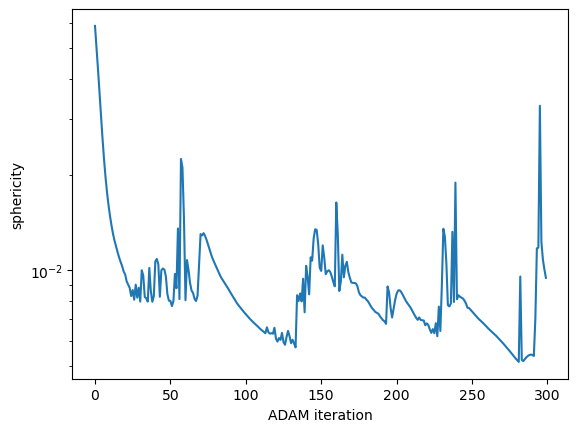

In [35]:
value_and_grad = jax.jit(jax.value_and_grad(loss_suzanne, has_aux=True))

params = (jnp.zeros(hemesh_suz.n_faces), jnp.zeros(hemesh_suz.n_faces))
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(params)
history_suz, best_fit, best_params = [], jnp.inf, params
for k in range(300):
    (L, fit), grads = value_and_grad(params, v0_suz)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    history_suz.append(fit)
    if fit < best_fit:
        best_fit, best_params = fit, params

v_sphered = relax_suzanne(best_params, v0_suz)
r = jnp.linalg.norm(v_sphered - v_sphered.mean(axis=0), axis=-1)
print(f"sphericity {history_suz[0]:.4f} -> {best_fit:.4f}, "
      f"std(r)/mean(r): {r.std()/r.mean():.3f} (initially 0.237)")
print(algo.get_mesh_quality_stats(v_sphered, hemesh_suz))

plt.semilogy(history_suz)
plt.xlabel("ADAM iteration"); plt.ylabel("sphericity");

In [36]:
# left: Suzanne (colored by radius); right: the "spherized" result with the
# optimized top director field, colored by relative radius deviation
r0_suz = np.array(jnp.linalg.norm(v0_suz - v0_suz.mean(axis=0), axis=-1))
p = meshplot.plot(np.array(v0_suz), np.array(hemesh_suz.faces), r0_suz,
                  shading={"wireframe": False}, return_plot=True)
p.add_mesh(np.array(v_sphered) + np.array([3.0, 0, 0]), np.array(hemesh_suz.faces),
           np.array(r / r.mean() - 1), shading={"wireframe": False})
p.add_lines(*director_segments(params[0], v_sphered, hemesh_suz, scale=0.05,
                               offset=np.array([3.0, 0, 0])),
            shading={"line_color": "red"})
p.save("tutorial_plots/06_suzanne_spherized.html")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.084027…

Plot saved to file tutorial_plots/06_suzanne_spherized.html.


In [37]:
IFrame(src="tutorial_plots/06_suzanne_spherized.html", width="100%", height=400)

The nematic pattern smooths Suzanne substantially toward a sphere — the protruding features (ears, snout) are the last to go, as they require the largest curvature changes. Increasing the actuation strength $\lambda$, decreasing the thickness, or running more ADAM iterations improves the result further. Because we optimized the cold-start objective, the design is *protocol-independent*: quasi-statically ramping $\lambda$ from 1 (slow heating) reaches the same final shape as the direct relaxation.

**Next step** (left for a future iteration of this tutorial): interpolate the optimized nematic fields from `suzanne_clean` onto a sphere mesh with *different* connectivity (using the `interp` module). Running the forward model on that sphere with the *inverse* actuation ($\lambda \to 1/\lambda$, i.e. cooling instead of heating) should then approximately reproduce Suzanne — completing the original design problem.